In [124]:
import os
import sys
import numpy as np
import pandas as pd
import geopandas as gpd

from exactextract import exact_extract
# import exactextract
from rasterio.warp import calculate_default_transform, reproject, Resampling
from shapely.geometry import box, shape
import shapely

import matplotlib.pyplot as plt

import xarray as xr
import rioxarray as rxr

from pyproj import Transformer


import rasterio
from rasterio.plot import show
import rasterio.merge
import glob

import shutil

from affine import Affine

from geotiff import GeoTiff

import warnings

# from osgeo import gdal

from matplotlib.collections import PolyCollection

sys.path.append("../utils")

nov_data_root = os.path.join(
    "/"
    "data",
    "wildfire_prep",
    "full_planet",
    "unzipped",
    "2020",
    "nov", 
    "files"
)

capstone_data_root = "/capstone/wildfire_prep/data"

master_geometries = gpd.read_file('/capstone/wildfire_prep/data/PUZZLE_PIECES/inspections_master_training_geometries.geojson')

# filepaths
ndvi_fp = '/data/wildfire_prep/ndvi'

import config

master_geometries = gpd.read_file('/capstone/wildfire_prep/data/PUZZLE_PIECES/inspections_master_training_geometries.geojson')
sb_county = gpd.read_file("/capstone/wildfire_prep/data/ca_counties/sb_county_boundary.shp")
send_polys = gpd.read_file('/capstone/wildfire_prep/josh/data-preparation/code/planet_tests/test_geojsons/geojson_io.geojson')

### Create filepath lists by month per year

In [2]:
fp = "/data/wildfire_prep/full_planet/unzipped"

month_sea = ["month_12", "month_11", "month_10", "month_09", "month_08", "month_07", "month_06", "month_05", "month_04", "month_03", "month_02", "month_01"]
month_name = ["dec", "nov", "oct", "sep", "aug", "jul", "jun", "may", "apr", "mar", "feb", "jan"]
year_sea = ["2019", "2020", "2021", "2022", "2023"]


In [3]:
for year in year_sea:
    for month in month_name: 
        init_list = []
        for root,dirs,files in os.walk(fp, topdown=True):
            for file in files:
                if "AnalyticMS_SR_clip_bandmath" in file and f'{year}/' in root and f'{month}/' in root and "reprojected" not in root:
                    init_list.append(f"{root}/{file}")
                    globals()[f"filepaths_{year}_{month}"] = init_list

In [4]:
filepaths_2019_dec

['/data/wildfire_prep/full_planet/unzipped/2019/dec/files/20191202_165715_1_1049_3B_AnalyticMS_SR_clip_bandmath.tif',
 '/data/wildfire_prep/full_planet/unzipped/2019/dec/files/20191227_181222_0e19_3B_AnalyticMS_SR_clip_bandmath.tif',
 '/data/wildfire_prep/full_planet/unzipped/2019/dec/files/20191205_165628_0f2a_3B_AnalyticMS_SR_clip_bandmath.tif',
 '/data/wildfire_prep/full_planet/unzipped/2019/dec/files/20191219_182603_1032_3B_AnalyticMS_SR_clip_bandmath.tif',
 '/data/wildfire_prep/full_planet/unzipped/2019/dec/files/20191216_182101_101f_3B_AnalyticMS_SR_clip_bandmath.tif',
 '/data/wildfire_prep/full_planet/unzipped/2019/dec/files/20191206_182547_0f34_3B_AnalyticMS_SR_clip_bandmath.tif',
 '/data/wildfire_prep/full_planet/unzipped/2019/dec/files/20191220_184204_39_106b_3B_AnalyticMS_SR_clip_bandmath.tif',
 '/data/wildfire_prep/full_planet/unzipped/2019/dec/files/20191219_165724_0f3c_3B_AnalyticMS_SR_clip_bandmath.tif',
 '/data/wildfire_prep/full_planet/unzipped/2019/dec/files/20191215_

In [17]:
with rasterio.open('/data/wildfire_prep/full_planet/unzipped/2019/dec/files/20191220_165357_1049_3B_AnalyticMS_SR_clip_bandmath.tif') as src:
    profile = src.profile
    layers = src.read().astype(np.float32)

    
    layers[layers == 0] = np.nan

profile.update(dtype=rasterio.float32, count=layers.shape[0])

with rasterio.open("test_dump/tif_masked.tif", "w", **profile) as dst:
    dst.write(layers)

In [23]:
xds = rxr.open_rasterio("test_dump/tif_masked.tif")

In [24]:
xds_reproj = xds.rio.reproject("EPSG:3310")

In [25]:
with rasterio.open('test_dump/tif_masked.tif') as src:
    print(f"Band count: {src.count}")  # Should be 5


Band count: 5


In [27]:
xds_reproj.rio.to_raster("test_dump/reproj.tif")

(-331968.337097594, -329854.4025870722)

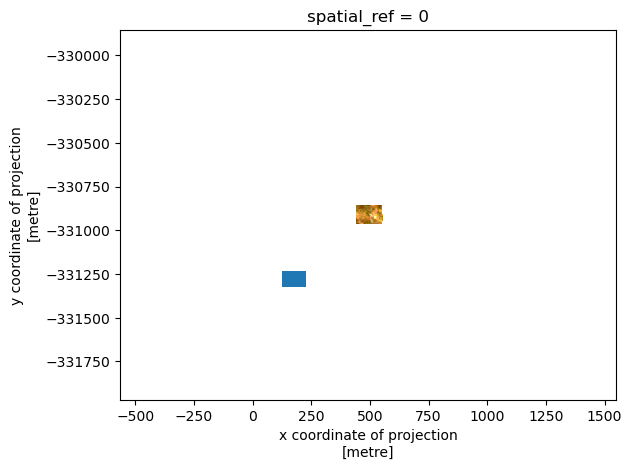

In [80]:
fig, ax = plt.subplots()

xmin, xmax = xds_reproj.x.min(), xds_reproj.x.max()
ymin, ymax = xds_reproj.y.min(), xds_reproj.y.max()


master_geometries.plot(ax = ax, zorder = -1)
xds_reproj.isel(band=[2, 1, 0]).plot.imshow(robust = True, ax = ax)


ax.set_xlim(xmin-1000, xmax+1000)
ax.set_ylim(ymin-1000, ymax+1000)

(-382814.4310640654, -380730.45294413384)

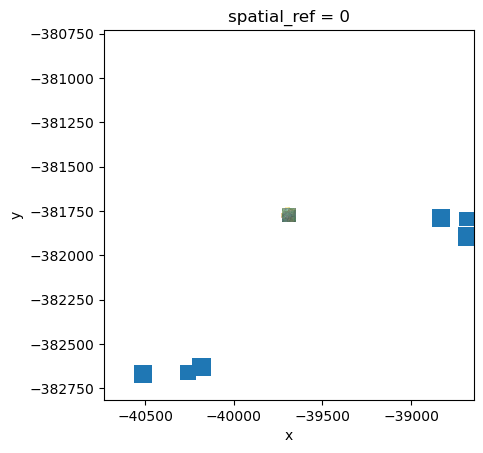

In [142]:
fig, ax = plt.subplots()

xmin, xmax = xds_reproj.x.min(), xds_reproj.x.max()
ymin, ymax = xds_reproj.y.min(), xds_reproj.y.max()



xds_reproj.isel(band=[2, 1, 0]).plot.imshow(robust = True, ax = ax, alpha = 0.5)
master_geometries.plot(ax = ax, zorder = -1)

ax.set_xlim(xmin-1000, xmax+1000)
ax.set_ylim(ymin-1000, ymax+1000)

In [94]:
for num, fp in enumerate(filepaths_2019_dec):
    with rasterio.open(fp) as src:
        profile = src.profile
        layers = src.read().astype(np.float32)

        
        layers[layers == 0] = np.nan

    profile.update(dtype=rasterio.float32, count=layers.shape[0])

    with rasterio.open(f"test_dump/all_dec_2019/masked/tif_masked_{num}.tif", "w", **profile) as dst:
        dst.write(layers)



In [ ]:
for root,dirs,files in os.walk("test_dump/all_dec_2019/masked", topdown=True):
    for file in files:
        print(f'{root}/{file}')

test_dump/all_dec_2019/tif_masked_51.tif
test_dump/all_dec_2019/tif_masked_108.tif
test_dump/all_dec_2019/tif_masked_193.tif
test_dump/all_dec_2019/tif_masked_115.tif
test_dump/all_dec_2019/tif_masked_180.tif
test_dump/all_dec_2019/tif_masked_170.tif
test_dump/all_dec_2019/tif_masked_211.tif
test_dump/all_dec_2019/tif_masked_98.tif
test_dump/all_dec_2019/tif_masked_56.tif
test_dump/all_dec_2019/tif_masked_109.tif
test_dump/all_dec_2019/tif_masked_35.tif
test_dump/all_dec_2019/tif_masked_67.tif
test_dump/all_dec_2019/tif_masked_149.tif
test_dump/all_dec_2019/tif_masked_225.tif
test_dump/all_dec_2019/tif_masked_171.tif
test_dump/all_dec_2019/tif_masked_9.tif
test_dump/all_dec_2019/tif_masked_230.tif
test_dump/all_dec_2019/tif_masked_125.tif
test_dump/all_dec_2019/tif_masked_49.tif
test_dump/all_dec_2019/tif_masked_57.tif
test_dump/all_dec_2019/tif_masked_236.tif
test_dump/all_dec_2019/tif_masked_74.tif
test_dump/all_dec_2019/tif_masked_100.tif
test_dump/all_dec_2019/tif_masked_220.tif
te

In [95]:
for root,dirs,files in os.walk("test_dump/all_dec_2019/masked", topdown=True):
    for num, file in enumerate(files):
        xds = rxr.open_rasterio(f'{root}/{file}')
        xds_reproj = xds.rio.reproject("EPSG:3310")
        xds_reproj.rio.to_raster(f"test_dump/all_dec_2019/reproj/reproj_{num}.tif")

In [97]:
for root,dirs,files in os.walk("test_dump/all_dec_2019/reproj", topdown=True):
    for num, file in enumerate(files):
        print(f'{root}/{file}')

test_dump/all_dec_2019/reproj/reproj_13.tif
test_dump/all_dec_2019/reproj/reproj_47.tif
test_dump/all_dec_2019/reproj/reproj_217.tif
test_dump/all_dec_2019/reproj/reproj_7.tif
test_dump/all_dec_2019/reproj/reproj_23.tif
test_dump/all_dec_2019/reproj/reproj_101.tif
test_dump/all_dec_2019/reproj/reproj_237.tif
test_dump/all_dec_2019/reproj/reproj_167.tif
test_dump/all_dec_2019/reproj/reproj_66.tif
test_dump/all_dec_2019/reproj/reproj_87.tif
test_dump/all_dec_2019/reproj/reproj_227.tif
test_dump/all_dec_2019/reproj/reproj_95.tif
test_dump/all_dec_2019/reproj/reproj_56.tif
test_dump/all_dec_2019/reproj/reproj_106.tif
test_dump/all_dec_2019/reproj/reproj_135.tif
test_dump/all_dec_2019/reproj/reproj_204.tif
test_dump/all_dec_2019/reproj/reproj_10.tif
test_dump/all_dec_2019/reproj/reproj_145.tif
test_dump/all_dec_2019/reproj/reproj_113.tif
test_dump/all_dec_2019/reproj/reproj_201.tif
test_dump/all_dec_2019/reproj/reproj_157.tif
test_dump/all_dec_2019/reproj/reproj_3.tif
test_dump/all_dec_2019

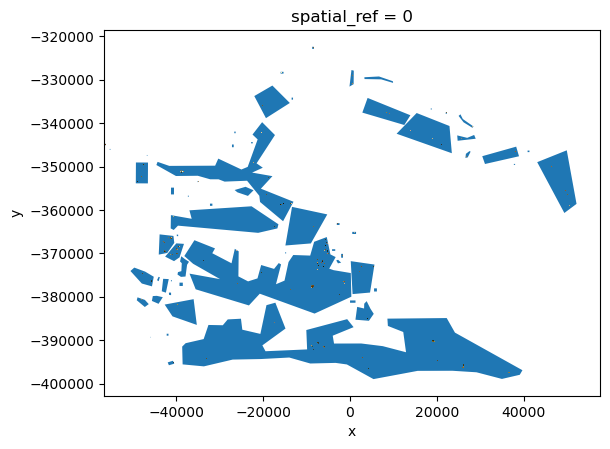

In [ ]:
fig, ax = plt.subplots()

# xmin, xmax = xds_reproj.x.min(), xds_reproj.x.max()
# ymin, ymax = xds_reproj.y.min(), xds_reproj.y.max()



for root,dirs,files in os.walk("test_dump/all_dec_2019/reproj", topdown=True):
    for file in files:
        xds_reproj = rxr.open_rasterio(f'{root}/{file}')
        xds_reproj.isel(band=[2, 1, 0]).plot.imshow(robust = True, ax = ax, alpha = 0.8)


# master_geometries.plot(ax = ax, zorder = -1)
send_polys.to_crs('EPSG:3310').plot(ax=ax, zorder = -1)

# ax.set_xlim(xmin-750, xmax+750)
# ax.set_ylim(ymin-750, ymax+750)

plt.show()

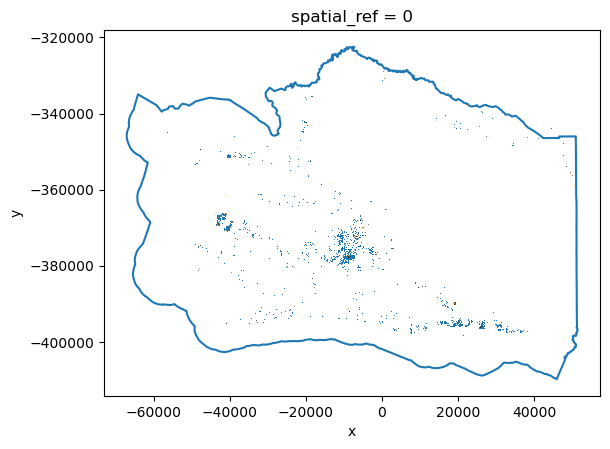

In [147]:
fig, ax = plt.subplots()



for root,dirs,files in os.walk("test_dump/all_dec_2019/reproj", topdown=True):
    for file in files:
        xds_reproj = rxr.open_rasterio(f'{root}/{file}')
        xds_reproj.isel(band=[2, 1, 0]).plot.imshow(robust = True, ax = ax, alpha = 0.8)


master_geometries.plot(ax = ax, zorder = -1)
sb_county.boundary.plot(ax=ax, zorder = -2)

plt.show()

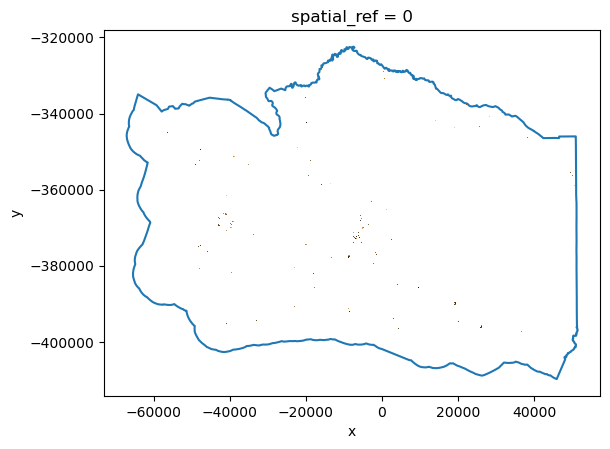

In [148]:
fig, ax = plt.subplots()



for root,dirs,files in os.walk("test_dump/all_dec_2019/reproj", topdown=True):
    for file in files:
        xds_reproj = rxr.open_rasterio(f'{root}/{file}')
        xds_reproj.isel(band=[2, 1, 0]).plot.imshow(robust = True, ax = ax, alpha = 0.8)


# master_geometries.plot(ax = ax, zorder = -1)
sb_county.boundary.plot(ax=ax, zorder = -2)

plt.show()

<Axes: >

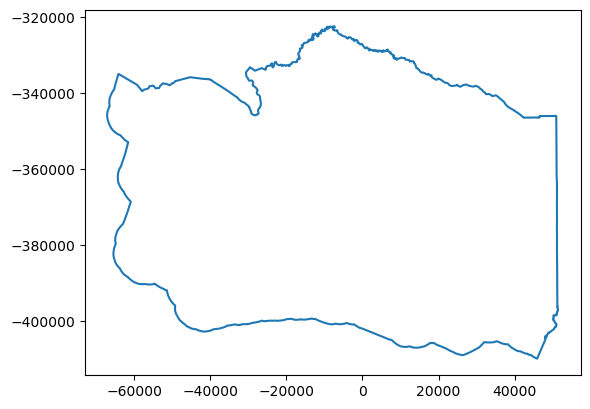

In [145]:
sb_county.boundary.plot()

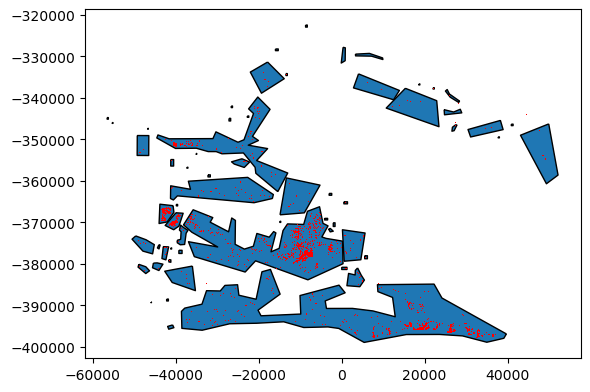

In [ ]:
fig, ax = plt.subplots()


master_geometries.plot(ax = ax, color = "red")
send_polys.to_crs('EPSG:3310').plot(ax=ax, zorder = -1, edgecolor="black")

plt.show()

In [127]:
shapely.get_num_coordinates(send_polys.iloc[0].geometry)

np.int32(44)

In [ ]:
for poly in send_polys["geometry"]:
    print(poly)

In [136]:
send_polys.iloc[0]

geometry    POLYGON ((-119.56772 34.44322, -119.73663 34.5...
Name: 0, dtype: geometry